# Bayesian Imputation for Ordinal Regression

This notebook demonstrates two approaches to **Bayesian imputation** within an ordinal regression model. Rather than imputing missing values as a preprocessing step, we incorporate imputation directly into the model, propagating uncertainty from missing data through to our final inferences.

## Why Bayesian Imputation?

Traditional approaches either:
- **Complete case analysis**: Drop observations with missing data (loses information, potential bias)
- **Single imputation**: Fill in missing values once (underestimates uncertainty)
- **Multiple imputation**: Generate multiple completed datasets (requires separate analysis step)

**Bayesian imputation** treats missing values as parameters to be estimated jointly with the model, automatically propagating uncertainty.

## Two Imputation Models

1. **Simple Categorical Imputation**: Missing values drawn from a categorical distribution based on the observed marginal distribution

2. **Regression-Based Imputation**: Missing values predicted by other observed variables (mental health indicators + demographics)

## Outcome Model

We predict **job satisfaction** (`satjob`, ordinal 1-4) using:
- `lifenow`: Life satisfaction rating (1-10, ordinal with ~50% missing)
- `hlthdep`: Health depression scale (1-5)
- `age`: Age in years (standardized)
- `female`: Binary indicator

Ordinal predictors use **monotonic effects** to respect their ordered nature without assuming equal spacing.

In [1]:
import multiprocessing
import platform

if platform.system() == "Linux":
    multiprocessing.set_start_method("spawn", force=True)

import pandas as pd
import numpy as np
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

np.random.seed(42)
pd.set_option('display.max_columns', None)

print(f'PyMC version: {pm.__version__}')
print(f'ArviZ version: {az.__version__}')

PyMC version: 5.27.0
ArviZ version: 0.22.0


## Data Loading and Exploration

In [ ]:
df = pd.read_csv('../data/gss_2022.csv')
print(f'Full dataset: {df.shape}')

# Variables for analysis
outcome = 'satjob'
impute_var = 'lifenow'
ordinal_predictors = ['hlthdep']  # simplified model
continuous_predictors = ['age']
binary_predictors = ['sex']

# Select columns and filter to valid outcome values
analysis_cols = [outcome, impute_var] + ordinal_predictors + continuous_predictors + binary_predictors
df_analysis = df[analysis_cols].copy()
df_analysis = df_analysis[df_analysis['satjob'].isin([1.0, 2.0, 3.0, 4.0])].copy()

# Drop rows missing other required predictors (but NOT lifenow)
required_cols = [outcome] + ordinal_predictors + continuous_predictors + binary_predictors
df_analysis = df_analysis.dropna(subset=required_cols).copy()

print(f'After filtering to valid satjob and complete predictors: {df_analysis.shape}')
print(f'LIFENOW missing: {df_analysis[impute_var].isna().sum()} ({df_analysis[impute_var].isna().mean()*100:.1f}%)')

In [3]:
# Examine LIFENOW distribution
print('LIFENOW distribution (observed values):')
lifenow_observed = df_analysis[impute_var].dropna()
print(lifenow_observed.value_counts().sort_index())

fig = make_subplots(rows=1, cols=2, subplot_titles=['LIFENOW (observed)', 'Job Satisfaction'])

# LIFENOW
counts = lifenow_observed.value_counts().sort_index()
fig.add_trace(
    go.Bar(x=[str(int(x)) for x in counts.index], y=counts.values, name='LIFENOW'),
    row=1, col=1
)

# Job satisfaction
sat_counts = df_analysis[outcome].value_counts().sort_index()
sat_labels = ['Very Sat.', 'Mod. Sat.', 'Little Dissat.', 'Very Dissat.']
fig.add_trace(
    go.Bar(x=sat_labels, y=sat_counts.values, name='satjob'),
    row=1, col=2
)

fig.update_layout(height=350, showlegend=False, title='Outcome and Imputation Variable Distributions')
fig.show()

LIFENOW distribution (observed values):
lifenow
1.0       1
3.0       4
4.0       9
5.0      32
6.0      52
7.0      47
8.0     129
9.0     166
10.0     66
Name: count, dtype: int64


In [4]:
# Check if missingness in LIFENOW is related to other variables
df_analysis['lifenow_missing'] = df_analysis[impute_var].isna().astype(int)

print('Missingness pattern analysis:')
print('\nMean values by LIFENOW missingness status:')
comparison = df_analysis.groupby('lifenow_missing')[['satjob', 'hlthdep', 'age']].mean()
comparison.index = ['Observed', 'Missing']
print(comparison.round(2))

print('\nSex distribution by missingness:')
print(pd.crosstab(df_analysis['lifenow_missing'], df_analysis['sex'], normalize='index').round(3))

Missingness pattern analysis:

Mean values by LIFENOW missingness status:
          satjob  hlthdep    age
Observed    1.71     2.26  43.87
Missing     1.73     2.16  44.02

Sex distribution by missingness:
sex                1.0    2.0
lifenow_missing              
0                0.512  0.488
1                0.340  0.660


In [5]:
# Prepare model data

# Outcome (0-indexed)
df_analysis['y'] = (df_analysis['satjob'] - 1).astype(int)

# Binary sex indicator
df_analysis['female'] = (df_analysis['sex'] == 2).astype(int)

# Standardize age
age_mean = df_analysis['age'].mean()
age_std = df_analysis['age'].std()
df_analysis['age_std'] = (df_analysis['age'] - age_mean) / age_std

# Convert ordinal predictors to 0-indexed
df_analysis['hlthdep_idx'] = (df_analysis['hlthdep'] - 1).astype(int)

# LIFENOW: 0-indexed where observed
df_analysis['lifenow_idx'] = df_analysis['lifenow'] - 1  # keeps NaN as NaN

# Identify observed vs missing indices
obs_mask = ~df_analysis['lifenow_idx'].isna()
obs_idx = np.where(obs_mask)[0]
miss_idx = np.where(~obs_mask)[0]

print(f'Observations with LIFENOW observed: {len(obs_idx)}')
print(f'Observations with LIFENOW missing: {len(miss_idx)}')

# Extract arrays
y = df_analysis['y'].values
N = len(y)
K_outcome = 4  # satjob categories
K_lifenow = 10  # lifenow categories (1-10)
K_hlthdep = 5  # hlthdep categories (1-5)

hlthdep_idx = df_analysis['hlthdep_idx'].values.astype(int)
age_std_arr = df_analysis['age_std'].values
female_arr = df_analysis['female'].values

# Observed LIFENOW values (0-indexed)
lifenow_obs_values = df_analysis.loc[obs_mask, 'lifenow_idx'].values.astype(int)

Observations with LIFENOW observed: 506
Observations with LIFENOW missing: 215


## Model 1: Simple Categorical Imputation

In this model, missing LIFENOW values are drawn from a categorical distribution whose probabilities are estimated from the observed data:

$$\text{LIFENOW}_\text{missing} \sim \text{Categorical}(\boldsymbol{\pi})$$

where $\boldsymbol{\pi} \sim \text{Dirichlet}(\boldsymbol{\alpha})$ with $\boldsymbol{\alpha}$ based on observed counts.

This assumes **Missing Completely at Random (MCAR)** - the probability of missingness doesn't depend on any variables.

In [6]:
# Compute prior from observed LIFENOW distribution
lifenow_counts = np.bincount(lifenow_obs_values, minlength=K_lifenow).astype(float)
lifenow_counts += 1  # add pseudocount for stability
print('LIFENOW observed counts (0-indexed):', lifenow_counts)
print('LIFENOW proportions:', (lifenow_counts / lifenow_counts.sum()).round(3))

LIFENOW observed counts (0-indexed): [  2.   1.   5.  10.  33.  53.  48. 130. 167.  67.]
LIFENOW proportions: [0.004 0.002 0.01  0.019 0.064 0.103 0.093 0.252 0.324 0.13 ]


In [7]:
with pm.Model() as model_categorical:
    
    # === Imputation Model for LIFENOW ===
    # Prior on category probabilities based on observed distribution
    pi_lifenow = pm.Dirichlet('pi_lifenow', a=lifenow_counts)
    
    # Impute missing values
    lifenow_imputed = pm.Categorical('lifenow_imputed', p=pi_lifenow, shape=len(miss_idx))
    
    # Combine observed and imputed into full array
    lifenow_full = pt.zeros(N, dtype='int64')
    lifenow_full = pt.set_subtensor(lifenow_full[obs_idx], lifenow_obs_values)
    lifenow_full = pt.set_subtensor(lifenow_full[miss_idx], lifenow_imputed)
    
    # === Monotonic Effect for LIFENOW ===
    b_lifenow = pm.Normal('b_lifenow', mu=0, sigma=2)  # scale
    delta_lifenow = pm.Dirichlet('delta_lifenow', a=np.ones(K_lifenow - 1))  # shape
    cumsum_lifenow = pt.concatenate([[0], pt.cumsum(delta_lifenow)])
    effect_lifenow = b_lifenow * cumsum_lifenow[lifenow_full]
    
    # === Monotonic Effect for HLTHDEP ===
    b_hlthdep = pm.Normal('b_hlthdep', mu=0, sigma=2)
    delta_hlthdep = pm.Dirichlet('delta_hlthdep', a=np.ones(K_hlthdep - 1))
    cumsum_hlthdep = pt.concatenate([[0], pt.cumsum(delta_hlthdep)])
    effect_hlthdep = b_hlthdep * cumsum_hlthdep[hlthdep_idx]
    
    # === Continuous/Binary Effects ===
    b_age = pm.Normal('b_age', mu=0, sigma=1)
    b_female = pm.Normal('b_female', mu=0, sigma=1)
    
    # === Linear Predictor ===
    eta = effect_lifenow + effect_hlthdep + b_age * age_std_arr + b_female * female_arr
    
    # === Ordinal Outcome ===
    cutpoints = pm.Normal('cutpoints', mu=[-1, 0, 1], sigma=2, shape=K_outcome - 1,
                         transform=pm.distributions.transforms.ordered)
    
    y_obs = pm.OrderedLogistic('y_obs', cutpoints=cutpoints, eta=eta, observed=y)

print('Model 1: Simple Categorical Imputation')
print(f'  Free parameters: pi_lifenow ({K_lifenow}), lifenow_imputed ({len(miss_idx)})')

Model 1: Simple Categorical Imputation
  Free parameters: pi_lifenow (10), lifenow_imputed (215)


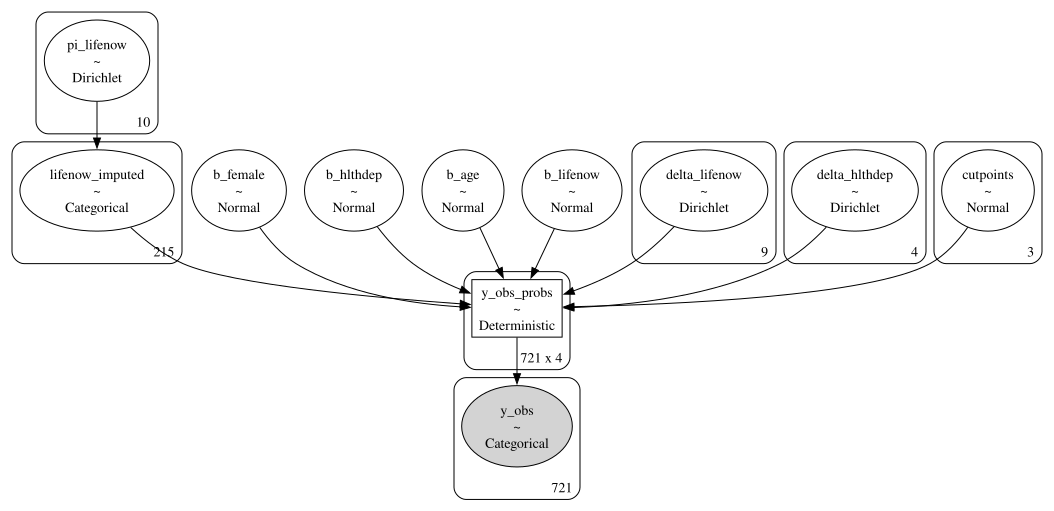

In [8]:
model_categorical.to_graphviz()

In [9]:
with model_categorical:
    trace_cat = pm.sample(
        draws=1000,
        tune=1000,
        target_accept=0.9,
    )
    pm.sample_posterior_predictive(trace_cat, extend_inferencedata=True)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [pi_lifenow, b_lifenow, delta_lifenow, b_hlthdep, delta_hlthdep, b_age, b_female, cutpoints]
>CategoricalGibbsMetropolis: [lifenow_imputed]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 121 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
Sampling: [y_obs]


Output()

In [10]:
# Diagnostics for Model 1
if 'diverging' in trace_cat.sample_stats:
    n_div = int(trace_cat.sample_stats['diverging'].sum().values)
    print(f'Divergent transitions: {n_div}')

print('\nCoefficient summary (Model 1 - Categorical Imputation):')
summary = az.summary(trace_cat, var_names=['b_lifenow', 'b_hlthdep', 'b_age', 'b_female', 'cutpoints'])
print(summary[['mean', 'sd', 'hdi_3%', 'hdi_97%', 'r_hat', 'ess_bulk']])

Divergent transitions: 0

Coefficient summary (Model 1 - Categorical Imputation):
               mean     sd  hdi_3%  hdi_97%  r_hat  ess_bulk
b_lifenow    -2.155  0.625  -3.420   -1.101    1.0    1539.0
b_hlthdep     2.010  0.361   1.354    2.690    1.0    2770.0
b_age        -0.349  0.077  -0.493   -0.202    1.0    3947.0
b_female      0.256  0.146  -0.027    0.519    1.0    4483.0
cutpoints[0] -1.018  0.549  -2.074   -0.068    1.0    1633.0
cutpoints[1]  1.374  0.541   0.371    2.348    1.0    1711.0
cutpoints[2]  2.819  0.562   1.704    3.771    1.0    1884.0


In [11]:
# Visualize imputed LIFENOW distribution
imputed_samples = trace_cat.posterior['lifenow_imputed'].values.flatten()

fig = make_subplots(rows=1, cols=2, subplot_titles=['Observed LIFENOW', 'Imputed LIFENOW (pooled posterior)'])

# Observed
obs_counts = np.bincount(lifenow_obs_values, minlength=K_lifenow)
obs_props = obs_counts / obs_counts.sum()
fig.add_trace(
    go.Bar(x=[str(i+1) for i in range(K_lifenow)], y=obs_props, name='Observed'),
    row=1, col=1
)

# Imputed (aggregate across all missing obs and draws)
imp_counts = np.bincount(imputed_samples.astype(int), minlength=K_lifenow)
imp_props = imp_counts / imp_counts.sum()
fig.add_trace(
    go.Bar(x=[str(i+1) for i in range(K_lifenow)], y=imp_props, name='Imputed'),
    row=1, col=2
)

fig.update_layout(height=350, title='Model 1: Observed vs Imputed LIFENOW Distribution')
fig.update_yaxes(title_text='Proportion')
fig.show()

print('Imputed distribution matches observed (by design - MCAR assumption)')

Imputed distribution matches observed (by design - MCAR assumption)


## Model 2: Regression-Based Imputation

In this model, missing LIFENOW values are predicted by other observed variables using an ordinal regression sub-model:

$$\text{LIFENOW}_i \sim \text{OrderedLogistic}(\eta^\text{imp}_i, \boldsymbol{c}^\text{imp})$$

where:
$$\eta^\text{imp}_i = \beta_0 + \beta_\text{hlthdep} \cdot \text{hlthdep}_i + \beta_\text{age} \cdot \text{age}_i + \beta_\text{female} \cdot \text{female}_i$$

This assumes **Missing at Random (MAR)** - missingness depends only on observed variables, not on LIFENOW itself.

In [12]:
with pm.Model() as model_regression:
    
    # === Imputation Sub-Model for LIFENOW ===
    # Predict LIFENOW from mental health + demographics
    imp_intercept = pm.Normal('imp_intercept', mu=0, sigma=2)
    imp_b_hlthdep = pm.Normal('imp_b_hlthdep', mu=0, sigma=1)
    imp_b_age = pm.Normal('imp_b_age', mu=0, sigma=1)
    imp_b_female = pm.Normal('imp_b_female', mu=0, sigma=1)
    
    # Linear predictor for imputation model (all observations)
    eta_imp = imp_intercept + imp_b_hlthdep * hlthdep_idx + imp_b_age * age_std_arr + imp_b_female * female_arr
    
    # Cutpoints for LIFENOW (9 cutpoints for 10 categories)
    imp_cutpoints = pm.Normal('imp_cutpoints', mu=np.linspace(-2, 2, K_lifenow - 1), sigma=2, 
                              shape=K_lifenow - 1,
                              transform=pm.distributions.transforms.ordered)
    
    # Likelihood for observed LIFENOW values
    lifenow_observed = pm.OrderedLogistic('lifenow_observed', 
                                          cutpoints=imp_cutpoints, 
                                          eta=eta_imp[obs_idx], 
                                          observed=lifenow_obs_values)
    
    # Impute missing LIFENOW values
    lifenow_imputed = pm.OrderedLogistic('lifenow_imputed',
                                         cutpoints=imp_cutpoints,
                                         eta=eta_imp[miss_idx],
                                         shape=len(miss_idx))
    
    # Combine observed and imputed
    lifenow_full = pt.zeros(N, dtype='int64')
    lifenow_full = pt.set_subtensor(lifenow_full[obs_idx], lifenow_obs_values)
    lifenow_full = pt.set_subtensor(lifenow_full[miss_idx], lifenow_imputed)
    
    # === Outcome Model (same as Model 1) ===
    
    # Monotonic Effect for LIFENOW
    b_lifenow = pm.Normal('b_lifenow', mu=0, sigma=2)
    delta_lifenow = pm.Dirichlet('delta_lifenow', a=np.ones(K_lifenow - 1))
    cumsum_lifenow = pt.concatenate([[0], pt.cumsum(delta_lifenow)])
    effect_lifenow = b_lifenow * cumsum_lifenow[lifenow_full]
    
    # Monotonic Effect for HLTHDEP
    b_hlthdep = pm.Normal('b_hlthdep', mu=0, sigma=2)
    delta_hlthdep = pm.Dirichlet('delta_hlthdep', a=np.ones(K_hlthdep - 1))
    cumsum_hlthdep = pt.concatenate([[0], pt.cumsum(delta_hlthdep)])
    effect_hlthdep = b_hlthdep * cumsum_hlthdep[hlthdep_idx]
    
    # Continuous/Binary Effects
    b_age = pm.Normal('b_age', mu=0, sigma=1)
    b_female = pm.Normal('b_female', mu=0, sigma=1)
    
    # Linear Predictor
    eta = effect_lifenow + effect_hlthdep + b_age * age_std_arr + b_female * female_arr
    
    # Ordinal Outcome
    cutpoints = pm.Normal('cutpoints', mu=[-1, 0, 1], sigma=2, shape=K_outcome - 1,
                         transform=pm.distributions.transforms.ordered)
    
    y_obs = pm.OrderedLogistic('y_obs', cutpoints=cutpoints, eta=eta, observed=y)

print('Model 2: Regression-Based Imputation')
print(f'  Imputation sub-model predicts LIFENOW from hlthdep, age, female')
print(f'  Missing observations to impute: {len(miss_idx)}')

Model 2: Regression-Based Imputation
  Imputation sub-model predicts LIFENOW from hlthdep, age, female
  Missing observations to impute: 215


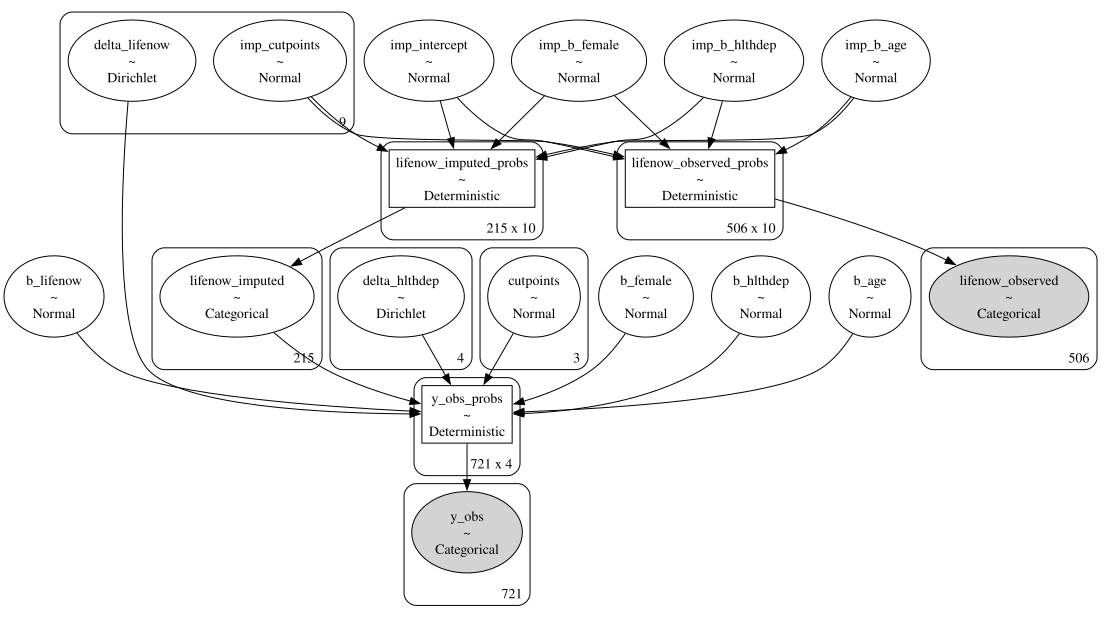

In [13]:
model_regression.to_graphviz()

In [15]:
with model_regression:
    trace_reg = pm.sample(
        draws=1000,
        tune=1000,
        target_accept=0.9,
    )
    pm.sample_posterior_predictive(trace_reg, extend_inferencedata=True)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [imp_intercept, imp_b_hlthdep, imp_b_age, imp_b_female, imp_cutpoints, b_lifenow, delta_lifenow, b_hlthdep, delta_hlthdep, b_age, b_female, cutpoints]
>CategoricalGibbsMetropolis: [lifenow_imputed]


Output()

/var/home/fonnesbeck/repos/Koenigsberg_Bayes/.pixi/envs/default/lib/python3.13/site-packages/pytensor/compile/function/types.py:1038: RuntimeWarning: invalid value encountered in accumulate
  outputs = vm() if output_subset is None else vm(output_subset=output_subset)


/var/home/fonnesbeck/repos/Koenigsberg_Bayes/.pixi/envs/default/lib/python3.13/site-packages/pytensor/compile/function/types.py:1038: RuntimeWarning: invalid value encountered in accumulate
  outputs = vm() if output_subset is None else vm(output_subset=output_subset)


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 230 seconds.
There were 15 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
Sampling: [lifenow_observed, y_obs]


Output()

In [16]:
# Diagnostics for Model 2
if 'diverging' in trace_reg.sample_stats:
    n_div = int(trace_reg.sample_stats['diverging'].sum().values)
    print(f'Divergent transitions: {n_div}')

print('\nOutcome model coefficients (Model 2 - Regression Imputation):')
summary_outcome = az.summary(trace_reg, var_names=['b_lifenow', 'b_hlthdep', 'b_age', 'b_female', 'cutpoints'])
print(summary_outcome[['mean', 'sd', 'hdi_3%', 'hdi_97%', 'r_hat', 'ess_bulk']])

print('\nImputation model coefficients:')
summary_imp = az.summary(trace_reg, var_names=['imp_intercept', 'imp_b_hlthdep', 'imp_b_age', 'imp_b_female'])
print(summary_imp[['mean', 'sd', 'hdi_3%', 'hdi_97%', 'r_hat', 'ess_bulk']])

Divergent transitions: 15

Outcome model coefficients (Model 2 - Regression Imputation):
               mean     sd  hdi_3%  hdi_97%  r_hat  ess_bulk
b_lifenow    -2.394  0.642  -3.577   -1.170    1.0    1754.0
b_hlthdep     1.736  0.360   1.054    2.403    1.0    3226.0
b_age        -0.341  0.079  -0.491   -0.199    1.0    5691.0
b_female      0.270  0.149   0.007    0.565    1.0    5549.0
cutpoints[0] -1.275  0.581  -2.392   -0.250    1.0    1999.0
cutpoints[1]  1.131  0.579   0.098    2.221    1.0    2116.0
cutpoints[2]  2.585  0.583   1.522    3.643    1.0    2217.0

Imputation model coefficients:
                mean     sd  hdi_3%  hdi_97%  r_hat  ess_bulk
imp_intercept  3.510  0.674   2.275    4.776    1.0    3854.0
imp_b_hlthdep -0.877  0.081  -1.024   -0.717    1.0    1152.0
imp_b_age      0.154  0.083  -0.001    0.309    1.0    1402.0
imp_b_female   0.055  0.160  -0.255    0.348    1.0    1324.0


In [17]:
# Compare observed and imputed distributions for Model 2
imputed_samples_reg = trace_reg.posterior['lifenow_imputed'].values.flatten()

fig = make_subplots(rows=1, cols=2, subplot_titles=['Observed LIFENOW', 'Imputed LIFENOW (regression model)'])

# Observed
fig.add_trace(
    go.Bar(x=[str(i+1) for i in range(K_lifenow)], y=obs_props, name='Observed'),
    row=1, col=1
)

# Imputed (regression model)
imp_counts_reg = np.bincount(imputed_samples_reg.astype(int), minlength=K_lifenow)
imp_props_reg = imp_counts_reg / imp_counts_reg.sum()
fig.add_trace(
    go.Bar(x=[str(i+1) for i in range(K_lifenow)], y=imp_props_reg, name='Imputed'),
    row=1, col=2
)

fig.update_layout(height=350, title='Model 2: Observed vs Imputed LIFENOW Distribution')
fig.update_yaxes(title_text='Proportion')
fig.show()

print('Note: Imputed distribution may differ from observed if predictors relate to missingness')

Note: Imputed distribution may differ from observed if predictors relate to missingness


## Model Comparison

In [18]:
# Compare coefficient estimates between models
params = ['b_lifenow', 'b_hlthdep', 'b_age', 'b_female']

comparison_data = []
for param in params:
    cat_samples = trace_cat.posterior[param].values.flatten()
    reg_samples = trace_reg.posterior[param].values.flatten()
    
    comparison_data.append({
        'Parameter': param,
        'Categorical Mean': cat_samples.mean(),
        'Categorical SD': cat_samples.std(),
        'Regression Mean': reg_samples.mean(),
        'Regression SD': reg_samples.std(),
        'Diff (Reg - Cat)': reg_samples.mean() - cat_samples.mean()
    })

comparison_df = pd.DataFrame(comparison_data)
print('=== COEFFICIENT COMPARISON ===')
print(comparison_df.to_string(index=False, float_format='{:.3f}'.format))

=== COEFFICIENT COMPARISON ===
Parameter  Categorical Mean  Categorical SD  Regression Mean  Regression SD  Diff (Reg - Cat)
b_lifenow            -2.155           0.624           -2.394          0.642            -0.240
b_hlthdep             2.010           0.361            1.736          0.360            -0.274
    b_age            -0.349           0.077           -0.341          0.079             0.007
 b_female             0.256           0.146            0.270          0.149             0.014


In [19]:
# Forest plot comparison
fig = go.Figure()

colors = {'Categorical': 'blue', 'Regression': 'red'}
offset = 0.15

for i, param in enumerate(params):
    # Categorical model
    cat_samples = trace_cat.posterior[param].values.flatten()
    cat_mean = cat_samples.mean()
    cat_hdi = np.percentile(cat_samples, [3, 97])
    
    fig.add_trace(go.Scatter(
        x=[cat_mean], y=[i - offset],
        error_x=dict(type='data', array=[cat_hdi[1] - cat_mean], arrayminus=[cat_mean - cat_hdi[0]]),
        marker=dict(size=10, color=colors['Categorical']),
        name='Categorical' if i == 0 else None,
        showlegend=(i == 0)
    ))
    
    # Regression model
    reg_samples = trace_reg.posterior[param].values.flatten()
    reg_mean = reg_samples.mean()
    reg_hdi = np.percentile(reg_samples, [3, 97])
    
    fig.add_trace(go.Scatter(
        x=[reg_mean], y=[i + offset],
        error_x=dict(type='data', array=[reg_hdi[1] - reg_mean], arrayminus=[reg_mean - reg_hdi[0]]),
        marker=dict(size=10, color=colors['Regression']),
        name='Regression' if i == 0 else None,
        showlegend=(i == 0)
    ))

fig.add_vline(x=0, line_dash='dash', line_color='gray')
fig.update_layout(
    title='Coefficient Comparison: Categorical vs Regression Imputation',
    xaxis_title='Coefficient Value',
    yaxis=dict(tickmode='array', tickvals=list(range(len(params))), ticktext=params),
    height=400
)
fig.show()

## Conclusions

### Key Findings

1. **Bayesian imputation** allows us to use all available data rather than dropping ~50% of observations with missing LIFENOW values.

2. **Simple categorical imputation** assumes MCAR - missing values follow the same distribution as observed. This is computationally simpler but may be biased if missingness relates to other variables.

3. **Regression-based imputation** assumes MAR - missingness can depend on observed variables. The imputation sub-model learns relationships between LIFENOW and predictors, potentially producing more accurate imputations.

4. **Uncertainty propagation**: Both models propagate imputation uncertainty through to the outcome model. Coefficients may have wider credible intervals than complete-case analysis would suggest.

### When to Use Each Approach

- **Categorical imputation**: When you believe missingness is truly random, or as a baseline comparison
- **Regression imputation**: When missingness may relate to observed variables (MAR), or when you want to leverage predictor relationships

### Limitations

- Neither approach handles **Missing Not at Random (MNAR)** - where missingness depends on the missing value itself
- Regression imputation requires additional model specification and assumptions
- Computational cost increases with the number of missing values